# Stochastic gradients break gradient samplers — $d=1$

The true target is $N(0, 1)$ with log-density $L(\theta) = -\tfrac12\theta^2$ and gradient $\nabla L(\theta) = -\theta$. Here the sampler sees the **exact value** but a
**stochastic gradient**

$$\widehat{\nabla}(\theta) = -\theta + \sigma\,\varepsilon(\theta), \qquad \varepsilon(\theta)\sim N(0, 1),$$

implemented with a `jax.custom_jvp` (the value is the primal; the noisy gradient is the tangent). This mirrors the CRN particle-filter regime, where the Fisher-identity gradient is a *consistent estimator of the true gradient that is decoupled from the value* — not the path derivative of the log-likelihood. The noise is **position-hashed** (a deterministic key folded from $\theta$), so the rough force field is CRN-reproducible yet effectively fresh at each $\theta$ a leapfrog step visits.

Because the *value* is exact, any departure of the samples from $N(0,1)$ is pure **gradient-noise pathology**: the force field $-\theta+\sigma\varepsilon(\theta)$ is non-conservative, so leapfrog stops conserving energy and divergences/rejections grow with $\sigma$. We sweep $\sigma$ and compare NUTS and WALNUTS.

In [1]:
import time
import warnings

warnings.filterwarnings("ignore")

import arviz as az
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from tqdm import tqdm

import manual_gaussian_inference as mgi

%matplotlib inline

DIM = 1
NUM_WARMUP = 2000
NUM_SAMPLES = 5000
N_REPS = 10
BASE_KEY = jr.PRNGKey(0)  # fixes the noise realization (same eps field across sigma)

In [2]:
# "Data" / ground truth: iid draws from the true N(0, 1).
system_truth = mgi.make_perturbed_gaussian_system(DIM)
truth = mgi.simulate_true_samples(jr.PRNGKey(0), system_truth, 2000)
reference = mgi.simulate_true_samples(jr.PRNGKey(1), system_truth, 50_000)


def make_logdensity(sigma):
    """Exact-value, noisy-gradient log-density at gradient-noise scale ``sigma``."""
    system = mgi.make_noisy_gradient_system(DIM, grad_noise_scale=float(sigma))
    return mgi.make_noisy_gradient_logdensity(system, BASE_KEY, value_mode="exact")

## Gradient field under a few $\sigma$

The thick line is the true gradient $-\theta$; the scatter is the rough field
$\widehat{\nabla}(\theta)$ the leapfrog integrator actually follows.

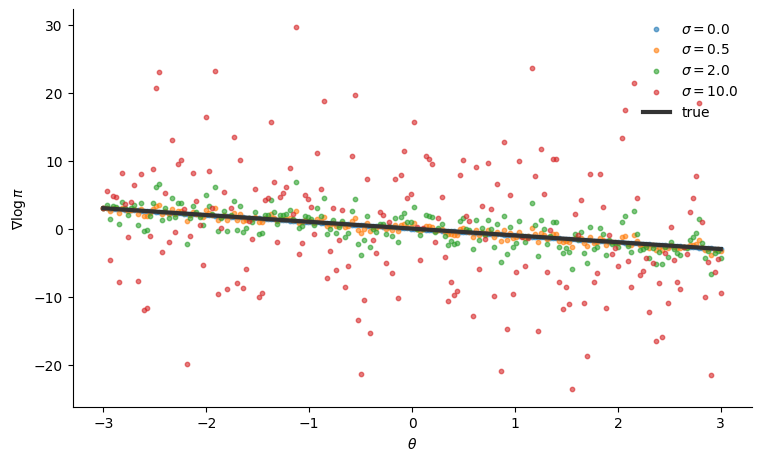

In [3]:
grad_grid = jnp.linspace(-3.0, 3.0, 200)
true_grad = -np.asarray(grad_grid)

sigmas_show = [0.0, 0.5, 2.0, 10.0]
noisy_grads, labels = [], []
for sig in sigmas_show:
    f = make_logdensity(sig)
    g = jax.vmap(jax.grad(f))(grad_grid[:, None]).reshape(-1)
    noisy_grads.append(np.asarray(g))
    labels.append(f"$\\sigma={sig}$")

fig, ax = mgi.plot_gradient_field(grad_grid, true_grad, noisy_grads, labels=labels)
plt.show()

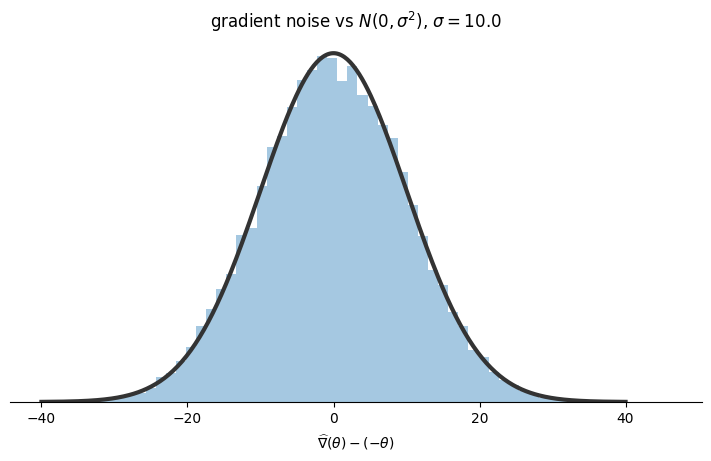

In [4]:
# The gradient noise is N(0, sigma^2) around -theta across positions. Collect the
# residual grad(theta) - (-theta) over a dense grid and compare to the Gaussian.
sigma_check = 10.0
f_check = make_logdensity(sigma_check)
dense = jnp.linspace(-4.0, 4.0, 20_000).reshape(-1, 1)
resid = np.asarray(jax.vmap(jax.grad(f_check))(dense)).reshape(-1) + np.asarray(dense).reshape(-1)

fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)
ax.hist(resid, bins=60, density=True, color="C0", alpha=0.4)
xs = np.linspace(-4 * sigma_check, 4 * sigma_check, 400)
ax.plot(xs, norm.pdf(xs, scale=sigma_check), color="0.2", linewidth=3.0)
ax.set_title(f"gradient noise vs $N(0,\\sigma^2)$, $\\sigma={sigma_check}$")
ax.set_xlabel(r"$\widehat{\nabla}(\theta) - (-\theta)$")
ax.set_yticks([])
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

## $\sigma$ sweep — divergence and ESS/s

Each grid point averages W1-to-truth and ESS/s over `N_REPS` independent runs, for NUTS
and WALNUTS.

In [5]:
sigma_grid = np.linspace(0.0, 100.0, 10)


def ess_min(samples):
    """Minimum effective sample size across coordinates (worst direction)."""
    arr = np.asarray(samples)
    return min(float(np.asarray(az.ess(arr[None, :, d]))) for d in range(arr.shape[1]))


def run_repeated(sampler, logdensity_fn, divergence_fn):
    """Run a sampler over N_REPS seeds; return (mean divergence, mean ESS/s, pooled
    samples). Wall-clock per run is end-to-end (JAX compile + warmup + sampling)."""
    divs, ess_rates, pooled = [], [], []
    for rep in range(N_REPS):
        t0 = time.perf_counter()
        result = sampler(
            logdensity_fn, rep, dim=DIM,
            num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES,
        )
        samples = np.asarray(jax.block_until_ready(result["samples"]))
        dt = time.perf_counter() - t0
        divs.append(divergence_fn(samples))
        ess_rates.append(ess_min(samples) / dt)
        pooled.append(samples)
    return float(np.mean(divs)), float(np.mean(ess_rates)), np.concatenate(pooled, 0)

In [6]:
n_s = len(sigma_grid)
div_nuts = np.full(n_s, np.nan)
div_walnuts = np.full(n_s, np.nan)
ess_nuts = np.full(n_s, np.nan)
ess_walnuts = np.full(n_s, np.nan)
divergence_fn = lambda s: mgi.wasserstein1_to_truth(s, reference)

for i_s in tqdm(range(n_s)):
    logdensity_fn = make_logdensity(sigma_grid[i_s])
    div_nuts[i_s], ess_nuts[i_s], _ = run_repeated(
        mgi.run_blackjax_nuts, logdensity_fn, divergence_fn
    )
    div_walnuts[i_s], ess_walnuts[i_s], _ = run_repeated(
        mgi.run_walnuts, logdensity_fn, divergence_fn
    )

100%|██████████| 10/10 [09:11<00:00, 55.13s/it]


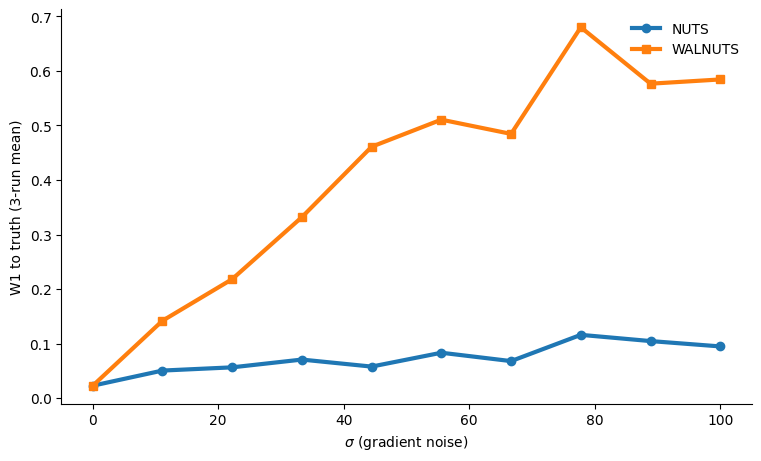

In [7]:
fig, _ = mgi.plot_sweep_nuts_walnuts(
    sigma_grid, div_nuts, div_walnuts,
    quantity_label="W1 to truth (3-run mean)",
)
plt.show()

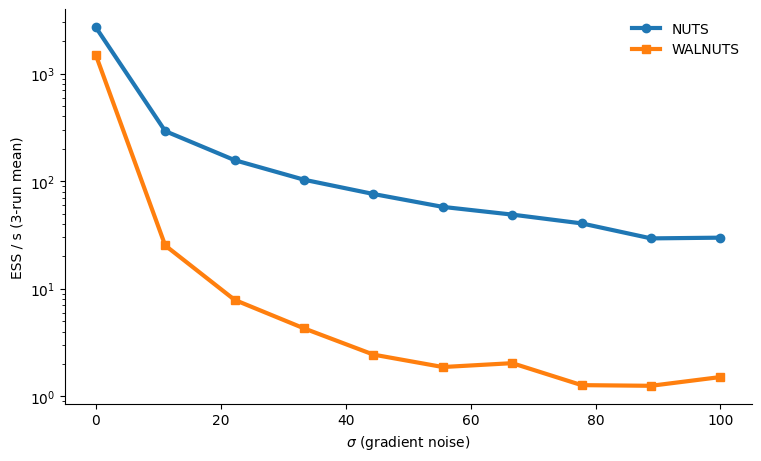

In [8]:
fig, _ = mgi.plot_sweep_nuts_walnuts(
    sigma_grid, ess_nuts, ess_walnuts,
    quantity_label="ESS / s (3-run mean)", log_y=True,
)
plt.show()

## Final histograms vs truth

The value is exact, so the stationary target *is* $N(0,1)$; the histograms show how the
stochastic gradient still distorts the samples as $\sigma$ grows.

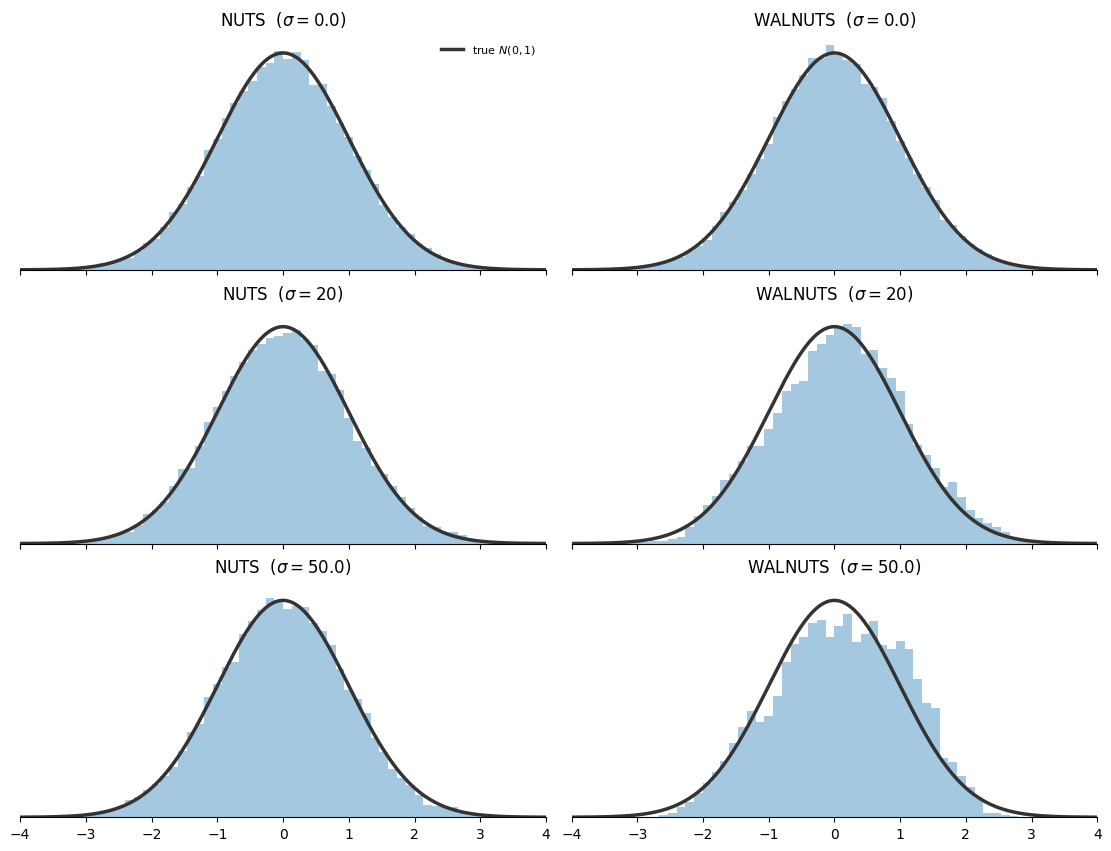

In [9]:
cases = [0.0, 20, 50.0]
grid_np = np.linspace(-4.0, 4.0, 600)
true_pdf = norm.pdf(grid_np)
bins = np.linspace(-4.0, 4.0, 61)

fig, axes = plt.subplots(
    len(cases), 2,
    figsize=(11, 2.8 * len(cases)),
    sharex=True, sharey=True, constrained_layout=True,
)

for row, sigma in enumerate(cases):
    logdensity_fn = make_logdensity(sigma)
    _, _, nuts_final = run_repeated(mgi.run_blackjax_nuts, logdensity_fn, lambda s: 0.0)
    _, _, walnuts_final = run_repeated(mgi.run_walnuts, logdensity_fn, lambda s: 0.0)

    for ax, samples, name in (
        (axes[row, 0], nuts_final, "NUTS"),
        (axes[row, 1], walnuts_final, "WALNUTS"),
    ):
        ax.hist(np.asarray(samples).ravel(), bins=bins, density=True, color="C0", alpha=0.4)
        ax.plot(grid_np, true_pdf, color="0.2", linewidth=2.5, label="true $N(0,1)$")
        ax.set_title(f"{name}  ($\\sigma={sigma}$)")
        ax.set_yticks([])
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)

axes[0, 0].set_xlim(-4.0, 4.0)
axes[0, 0].legend(loc="upper right", frameon=False, fontsize=8)
plt.show()

## Noisy likelihood, exact gradients

The mirror image of the first section: the **gradient is now exact** ($-\theta$, so leapfrog follows the *true* Hamiltonian and proposes good moves), but the **value is noisy** $\widehat L(\theta) = -\tfrac12\theta^2 + \eta(\theta)$, $\eta(\theta)\sim N(0,\sigma_L^2)$ (position-hashed). This isolates the Metropolis correction: HMC accepts in proportion to the *noisy* energy gap $\eta(\theta')-\eta(\theta)$, so the chain climbs the noise field and gets trapped at its spikes. Any bias here comes purely from a corrupted accept/reject — **not** from the dynamics — pinpointing the noisy *value*, not the noisy gradient, as the source of the DPF bias.

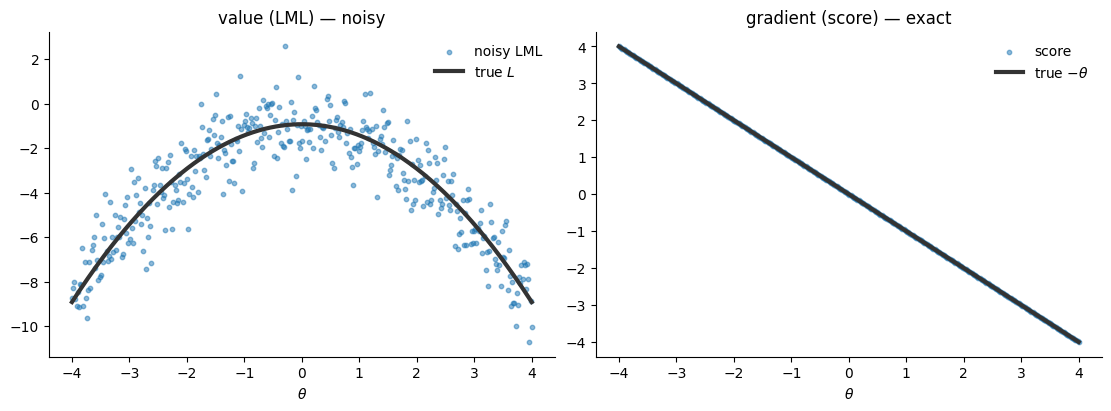

In [10]:
def make_logdensity_noisyval(value_std):
    """Exact-gradient, noisy-value log-density at LML-noise std ``value_std``."""
    system = mgi.make_noisy_gradient_system(
        DIM, grad_noise_scale=0.0, value_noise_scale=float(value_std)
    )
    return mgi.make_noisy_gradient_logdensity(system, BASE_KEY, value_mode="noisy")


sigma_L_demo = 1.0  # LML noise std for the visual (variance 1)
nv_logdensity = make_logdensity_noisyval(sigma_L_demo)

vis_grid = jnp.linspace(-4.0, 4.0, 400)
vis_np = np.asarray(vis_grid)
true_val = np.asarray(jax.vmap(lambda t: mgi.true_log_density(system_truth, t[None]))(vis_grid))
noisy_val = np.asarray(jax.vmap(nv_logdensity)(vis_grid[:, None]))
exact_score = np.asarray(jax.vmap(jax.grad(nv_logdensity))(vis_grid[:, None])).reshape(-1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
axL.scatter(vis_np, noisy_val, s=10, alpha=0.5, color="C0", label="noisy LML")
axL.plot(vis_np, true_val, color="0.2", linewidth=3.0, label="true $L$", zorder=3)
axL.set_title("value (LML) — noisy")
axL.set_xlabel(r"$\theta$")
axL.legend(frameon=False)

axR.scatter(vis_np, exact_score, s=10, alpha=0.5, color="C0", label="score")
axR.plot(vis_np, -vis_np, color="0.2", linewidth=3.0, label=r"true $-\theta$", zorder=3)
axR.set_title("gradient (score) — exact")
axR.set_xlabel(r"$\theta$")
axR.legend(frameon=False)

for ax in (axL, axR):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.show()

### Final histograms vs truth

As $\sigma_L$ grows the perfect dynamics keep proposing well, but the corrupted accept step traps the chain — the marginal stays $N(0,1)$ until it abruptly collapses.

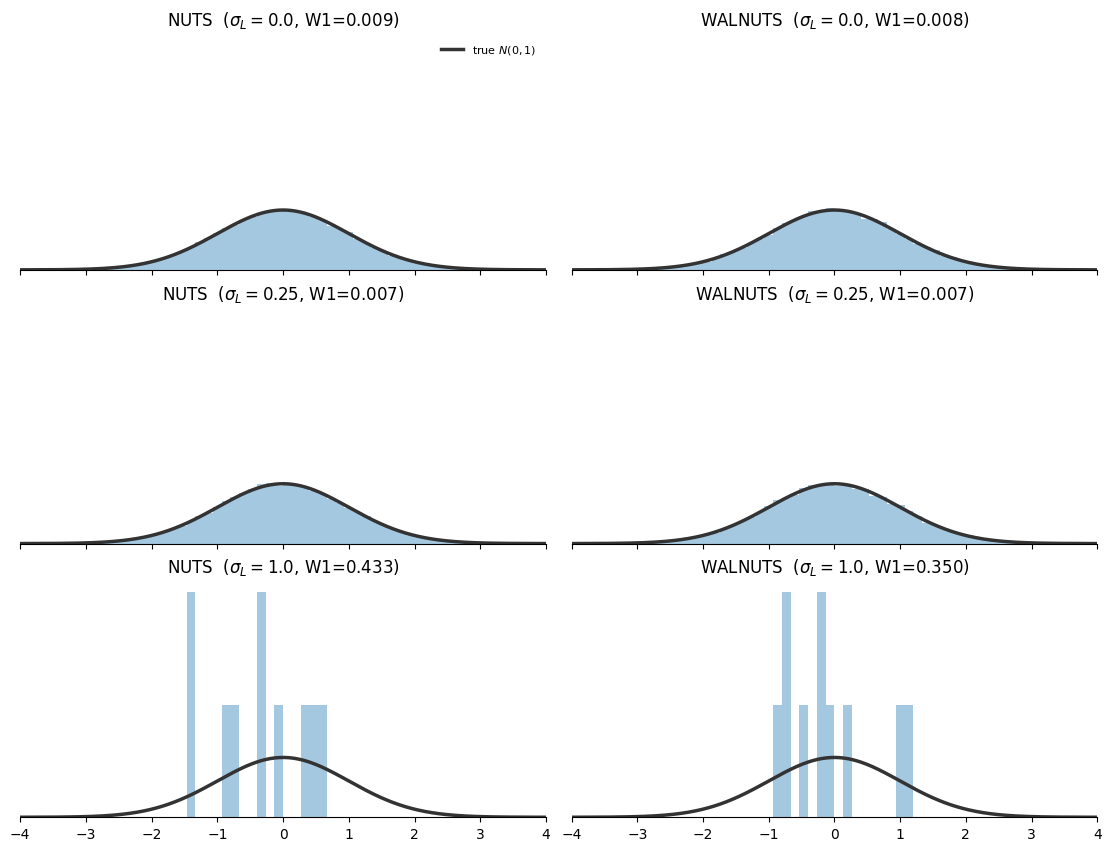

In [11]:
cases_nv = [0.0, 0.25, 1.0]
fig, axes = plt.subplots(
    len(cases_nv), 2,
    figsize=(11, 2.8 * len(cases_nv)),
    sharex=True, sharey=True, constrained_layout=True,
)

for row, sL in enumerate(cases_nv):
    ld = make_logdensity_noisyval(sL)
    _, _, nuts_s = run_repeated(mgi.run_blackjax_nuts, ld, lambda s: 0.0)
    _, _, walnuts_s = run_repeated(mgi.run_walnuts, ld, lambda s: 0.0)
    for ax, samples, name in (
        (axes[row, 0], nuts_s, "NUTS"),
        (axes[row, 1], walnuts_s, "WALNUTS"),
    ):
        ax.hist(np.asarray(samples).ravel(), bins=bins, density=True, color="C0", alpha=0.4)
        ax.plot(grid_np, true_pdf, color="0.2", linewidth=2.5, label="true $N(0,1)$")
        w1 = mgi.wasserstein1_to_truth(samples, reference)
        ax.set_title(f"{name}  ($\\sigma_L={sL}$, W1={w1:.3f})")
        ax.set_yticks([])
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)

axes[0, 0].set_xlim(-4.0, 4.0)
axes[0, 0].legend(loc="upper right", frameon=False, fontsize=8)
plt.show()

### LML-noise sweep

W1 to truth as the LML-noise std $\sigma_L$ increases, with the gradient held exact. The threshold matches the combined (DPF) sweep below — confirming the value noise alone drives the bias.

100%|██████████| 8/8 [26:19<00:00, 197.42s/it]


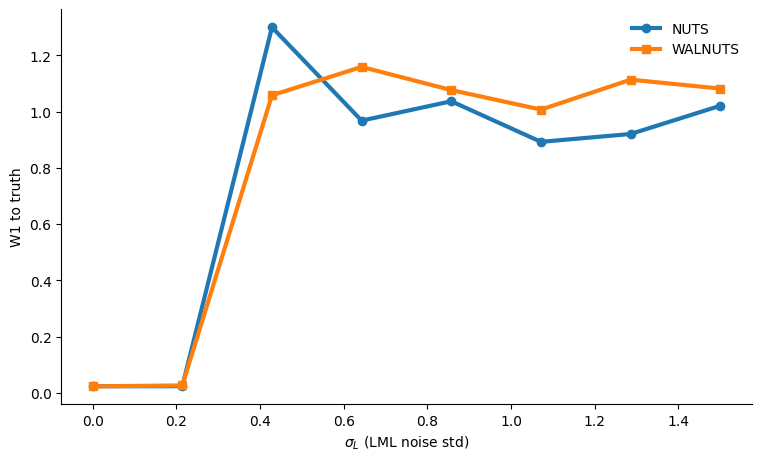

In [12]:
value_std_grid_nv = np.linspace(0.0, 1.5, 8)
w1_nuts_nv = np.full(len(value_std_grid_nv), np.nan)
w1_walnuts_nv = np.full(len(value_std_grid_nv), np.nan)

for i_v, sL in enumerate(tqdm(value_std_grid_nv)):
    ld = make_logdensity_noisyval(sL)
    w1_nuts_nv[i_v], _, _ = run_repeated(mgi.run_blackjax_nuts, ld, divergence_fn)
    w1_walnuts_nv[i_v], _, _ = run_repeated(mgi.run_walnuts, ld, divergence_fn)

fig, ax = mgi.plot_sweep_nuts_walnuts(
    value_std_grid_nv, w1_nuts_nv, w1_walnuts_nv,
    quantity_label="W1 to truth", xlabel=r"$\sigma_L$ (LML noise std)",
)
plt.show()

## Combining noisy LML **and** noisy score — the DPF regime

The section above keeps the **value exact**, so NUTS/WALNUTS Metropolize against the *true* energy and the marginal stays $\approx N(0,1)$ no matter how rough the gradient — exactly why pure score noise barely moved the histograms. A differentiable particle filter is noisier than that: **both** the log-marginal-likelihood (LML) *value* and the score *gradient* are stochastic, and they are mutually inconsistent. Once the value is noisy, the Metropolis correction targets the *wrong* density, and the bias a DPF exhibits appears.

The sampler now sees

$$\widehat L(\theta) = -\tfrac12\theta^2 + \eta(\theta),\ \ \eta(\theta)\sim N(0,\sigma_L^2);\qquad \widehat\nabla(\theta) = -\theta + \varepsilon(\theta),\ \ \varepsilon(\theta)\sim N(0,\sigma_S^2),$$

with $\sigma_L^2 = 1$ (LML) and $\sigma_S^2 = 40$ (score), as independent position-hashed fields (values reported as **variances**; the `*_noise_scale` arguments take the std $\sqrt{\cdot}$).

> **Modeling note.** This LML noise is *white* (independent per position), the maximally-rough limit. A real CRN particle-filter LML is rough but *continuous* — a single sample path with a finite correlation length (`plan.md`'s GP idea). White value noise therefore tends to **trap** the chain at the tallest noise spike (the marginal collapses) rather than biasing it smoothly; the qualitative lesson is the same — a noisy *value* breaks the Metropolis guarantee that exact-value + noisy-gradient preserved.

In [13]:
LML_NOISE_VAR = 1.0     # N(0, 1) on the log-marginal-likelihood value
SCORE_NOISE_VAR = 40.0  # N(0, 40) on the score / gradient

dpf_system = mgi.make_noisy_gradient_system(
    DIM,
    grad_noise_scale=np.sqrt(SCORE_NOISE_VAR),
    value_noise_scale=np.sqrt(LML_NOISE_VAR),
)
dpf_logdensity = mgi.make_noisy_gradient_logdensity(
    dpf_system, BASE_KEY, value_mode="noisy"
)

### The two corrupted quantities

Left: the noisy LML value around the true $-\tfrac12\theta^2$. Right: the noisy score around the true $-\theta$.

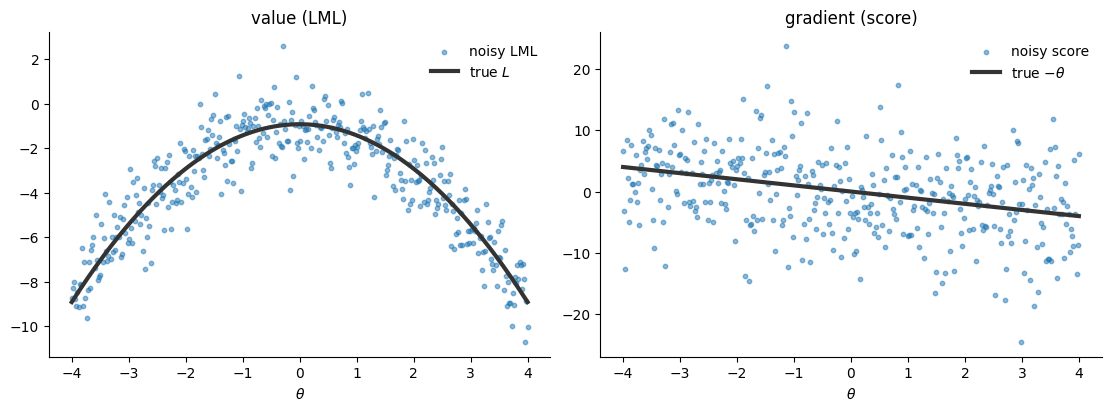

In [14]:
vis_grid = jnp.linspace(-4.0, 4.0, 400)
vis_np = np.asarray(vis_grid)

true_val = np.asarray(jax.vmap(lambda t: mgi.true_log_density(system_truth, t[None]))(vis_grid))
noisy_val = np.asarray(jax.vmap(dpf_logdensity)(vis_grid[:, None]))
true_score = -vis_np
noisy_score = np.asarray(jax.vmap(jax.grad(dpf_logdensity))(vis_grid[:, None])).reshape(-1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
axL.scatter(vis_np, noisy_val, s=10, alpha=0.5, color="C0", label="noisy LML")
axL.plot(vis_np, true_val, color="0.2", linewidth=3.0, label="true $L$", zorder=3)
axL.set_title("value (LML)")
axL.set_xlabel(r"$\theta$")
axL.legend(frameon=False)

axR.scatter(vis_np, noisy_score, s=10, alpha=0.5, color="C0", label="noisy score")
axR.plot(vis_np, true_score, color="0.2", linewidth=3.0, label=r"true $-\theta$", zorder=3)
axR.set_title("gradient (score)")
axR.set_xlabel(r"$\theta$")
axR.legend(frameon=False)

for ax in (axL, axR):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.show()

### Score noise alone vs score + LML noise

Same score noise ($\sigma_S^2 = 40$) in both rows. **Top:** value exact — the marginal is preserved. **Bottom:** value also noisy ($\sigma_L^2 = 1$) — the Metropolis correction is corrupted and the samples collapse / bias away from $N(0,1)$.

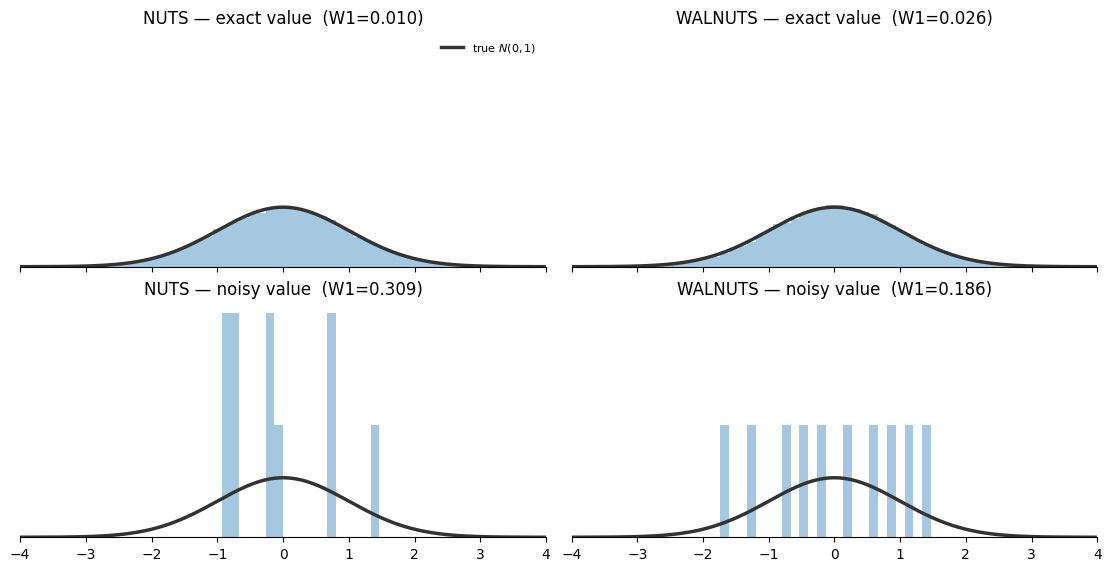

In [15]:
configs = [
    (
        "exact value",
        mgi.make_noisy_gradient_logdensity(
            mgi.make_noisy_gradient_system(DIM, grad_noise_scale=np.sqrt(SCORE_NOISE_VAR)),
            BASE_KEY, value_mode="exact",
        ),
    ),
    ("noisy value", dpf_logdensity),
]

fig, axes = plt.subplots(
    len(configs), 2,
    figsize=(11, 2.8 * len(configs)),
    sharex=True, sharey=True, constrained_layout=True,
)

for row, (label, ld) in enumerate(configs):
    _, _, nuts_s = run_repeated(mgi.run_blackjax_nuts, ld, lambda s: 0.0)
    _, _, walnuts_s = run_repeated(mgi.run_walnuts, ld, lambda s: 0.0)
    for ax, samples, name in (
        (axes[row, 0], nuts_s, "NUTS"),
        (axes[row, 1], walnuts_s, "WALNUTS"),
    ):
        ax.hist(np.asarray(samples).ravel(), bins=bins, density=True, color="C0", alpha=0.4)
        ax.plot(grid_np, true_pdf, color="0.2", linewidth=2.5, label="true $N(0,1)$")
        w1 = mgi.wasserstein1_to_truth(samples, reference)
        ax.set_title(f"{name} — {label}  (W1={w1:.3f})")
        ax.set_yticks([])
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)

axes[0, 0].set_xlim(-4.0, 4.0)
axes[0, 0].legend(loc="upper right", frameon=False, fontsize=8)
plt.show()

### How much LML noise is too much?

Fix the score noise at $\sigma_S^2 = 40$ and sweep the LML-noise std $\sigma_L$. Small $\sigma_L$ keeps the marginal correct (the spikes are too small to trap the chain); past a threshold the chain sticks at a noise spike and W1 jumps.

100%|██████████| 8/8 [25:57<00:00, 194.71s/it]


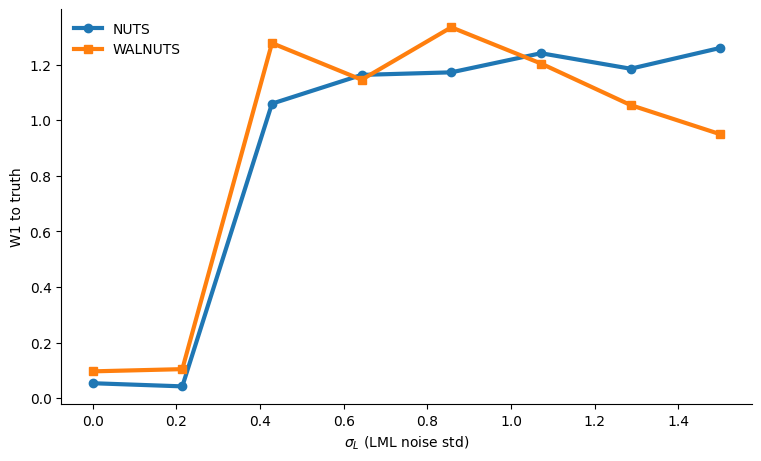

In [16]:
value_std_grid = np.linspace(0.0, 1.5, 8)
w1_nuts_v = np.full(len(value_std_grid), np.nan)
w1_walnuts_v = np.full(len(value_std_grid), np.nan)

for i_v, vstd in enumerate(tqdm(value_std_grid)):
    system = mgi.make_noisy_gradient_system(
        DIM, grad_noise_scale=np.sqrt(SCORE_NOISE_VAR), value_noise_scale=float(vstd)
    )
    ld = mgi.make_noisy_gradient_logdensity(system, BASE_KEY, value_mode="noisy")
    w1_nuts_v[i_v], _, _ = run_repeated(mgi.run_blackjax_nuts, ld, divergence_fn)
    w1_walnuts_v[i_v], _, _ = run_repeated(mgi.run_walnuts, ld, divergence_fn)

fig, ax = mgi.plot_sweep_nuts_walnuts(
    value_std_grid, w1_nuts_v, w1_walnuts_v,
    quantity_label="W1 to truth", xlabel=r"$\sigma_L$ (LML noise std)",
)
plt.show()

## Heatmap matrix: LML noise $\sigma_L$ × score noise $\sigma_S$

The full 2-D picture. We grid over the LML-noise std $\sigma_L \in \{0, 0.01, 0.1, 1\}$ (the *value*, which corrupts the Metropolis correction) and the score-noise std $\sigma_S \in \{0, 1, 10, 100\}$ (the *gradient*, which corrupts the dynamics), and report W1-to-truth (bias) and ESS/s (efficiency) for NUTS and WALNUTS on shared color scales.

This is the summary of the three sections above: **W1 is governed almost entirely by $\sigma_L$** — bias enters only once the value is noisy — while **ESS/s falls with both**, driven down the $\sigma_S$ axis (gradient noise shortens trajectories / forces refinement) and collapsing in the noisy-value corner.

In [17]:
sigma_L_grid = np.array([0.0, 0.01, 0.1, 1.0])
sigma_S_grid = np.array([0.0, 1.0, 10.0, 100.0])

n_S, n_L = len(sigma_S_grid), len(sigma_L_grid)
w1_nuts_mat = np.full((n_S, n_L), np.nan)
w1_walnuts_mat = np.full((n_S, n_L), np.nan)
ess_nuts_mat = np.full((n_S, n_L), np.nan)
ess_walnuts_mat = np.full((n_S, n_L), np.nan)

# value_mode="noisy" with value_noise_scale=0 reproduces the exact value, so the whole
# matrix (including the sigma_L=0 column) is one consistent family.
for i_S, sS in enumerate(tqdm(sigma_S_grid)):
    for j_L, sL in enumerate(tqdm(sigma_L_grid, leave=False)):
        system = mgi.make_noisy_gradient_system(
            DIM, grad_noise_scale=float(sS), value_noise_scale=float(sL)
        )
        ld = mgi.make_noisy_gradient_logdensity(system, BASE_KEY, value_mode="noisy")
        w1_nuts_mat[i_S, j_L], ess_nuts_mat[i_S, j_L], _ = run_repeated(
            mgi.run_blackjax_nuts, ld, divergence_fn
        )
        w1_walnuts_mat[i_S, j_L], ess_walnuts_mat[i_S, j_L], _ = run_repeated(
            mgi.run_walnuts, ld, divergence_fn
        )

100%|██████████| 4/4 [26:00<00:00, 390.12s/it]


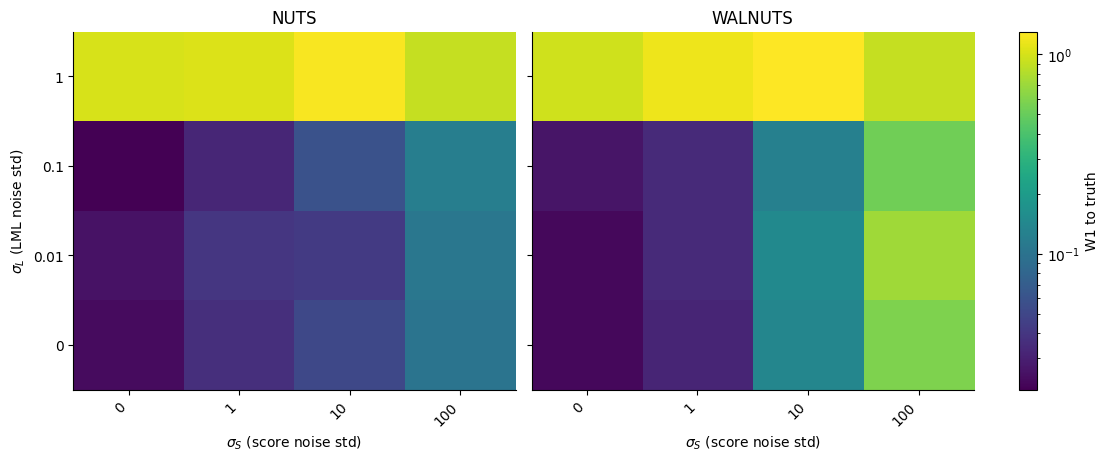

In [18]:
fig, _ = mgi.plot_nuts_walnuts_heatmaps(
    sigma_S_grid, sigma_L_grid, w1_nuts_mat, w1_walnuts_mat,
    quantity_label="W1 to truth",
    xlabel=r"$\sigma_S$ (score noise std)",
    ylabel=r"$\sigma_L$ (LML noise std)",
    log_color=True,
)
plt.show()

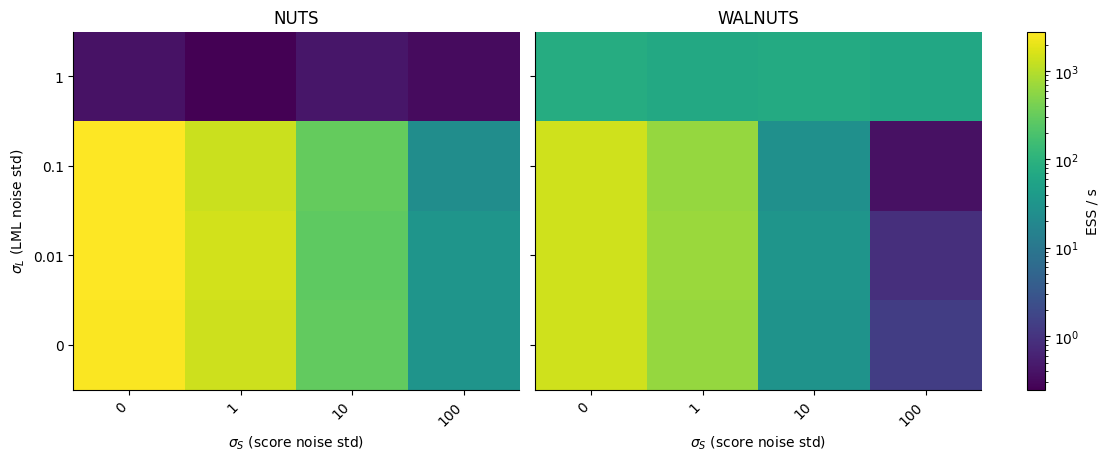

In [19]:
fig, _ = mgi.plot_nuts_walnuts_heatmaps(
    sigma_S_grid, sigma_L_grid, ess_nuts_mat, ess_walnuts_mat,
    quantity_label="ESS / s",
    xlabel=r"$\sigma_S$ (score noise std)",
    ylabel=r"$\sigma_L$ (LML noise std)",
    log_color=True,
)
plt.show()